In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler


In [3]:
data=pd.read_csv("CarPrice_Assignment.csv")
print(data.head())
print(data.info())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [4]:
data=data.drop(['CarName','car_ID'],axis=1)
data=pd.get_dummies(data,drop_first=True)

In [5]:
X=data.drop('price',axis=1)
y=data['price']

In [7]:
scaler=StandardScaler()
X=scaler.fit_transform(X)
y=scaler.fit_transform(np.array(y).reshape(-1,1))

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
sgd_model=SGDRegressor(max_iter=1000,tol=1e-3)

In [11]:
sgd_model.fit(X_train,y_train)

C:\ProgramData\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor()

In [12]:
y_pred=sgd_model.predict(X_test)

In [16]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)

In [17]:
print('Name:Varoodhini M')
print('Reg No:212225220118')
print("Mean Squared Error:",mse)
print("R-squared Score:",r2)

Name:Varoodhini M
Reg No:212225220118
Mean Squared Error: 0.2154970117902742
R-squared Score: 0.8266327328648231


In [18]:
print("\nModel Coefficients:")
print("Coefficients:",sgd_model.coef_)
print("Intercept:",sgd_model.intercept_)


Model Coefficients:
Coefficients: [ 0.03342878  0.10956078  0.01582313  0.17276441  0.01815515  0.16312784
  0.28420619 -0.01602348 -0.08256065  0.00265342  0.10294691  0.0391678
 -0.0390771  -0.04967982 -0.01686634  0.02186633  0.02083317 -0.01523745
 -0.08830727 -0.01518734 -0.09424457 -0.03439757  0.05873791  0.20883728
  0.01690998 -0.10222905  0.06944984 -0.01743925  0.00525004  0.0104543
 -0.030168   -0.14349537 -0.06978798  0.00082584 -0.02294195  0.0104543
 -0.00454119 -0.01328128  0.01686634 -0.0173609  -0.0309935  -0.03864576
 -0.01582203]
Intercept: [-0.01179499]


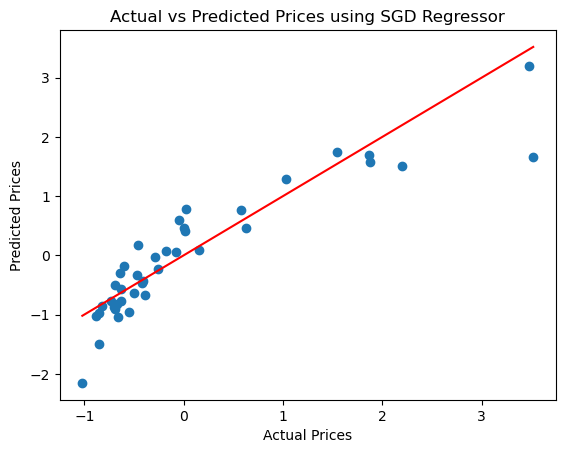

In [20]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices using SGD Regressor")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='red')
plt.show()